In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys, os
sys.path.append(os.path.abspath(".."))
from config import ENGINE
warnings.filterwarnings("ignore")
engine = ENGINE

In [3]:
sns.set_style("whitegrid")

In [4]:
df = pd.read_sql("SELECT * FROM car_data_cleaned", engine)
df.head()

,id,name,price,year,body_type,status,origin,mileage,fuel_type,brand,age
0,1,Toyota Fortuner 2.4G 4x2 AT 2017,525000000,2017,SUV,Xe cũ,Nhập khẩu,135.0,dầu,Toyota,8
1,2,Suzuki Swift 1.4 AT 2013,269000000,2013,Hatchback,Xe cũ,Nhập khẩu,132000.0,xăng,Suzuki,12
2,3,Hyundai Stargazer 1.5 AT Cao cấp 2022,455000000,2022,MPV,Xe cũ,Nhập khẩu,72000.0,xăng,Hyundai,3
3,4,Nissan X trail 2018,465000000,2018,SUV,Xe cũ,Trong nước,110000.0,xăng,Nissan,7
4,5,Mazda 3 Sedan 1.5L Luxury 2016,360000000,2016,Sedan,Xe cũ,Nhập khẩu,79000.0,xăng,Mazda,9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7184 entries, 0 to 7183
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7184 non-null   int64  
 1   name       7184 non-null   object 
 2   price      7184 non-null   int64  
 3   year       7184 non-null   int64  
 4   body_type  7184 non-null   object 
 5   status     7184 non-null   object 
 6   origin     7184 non-null   object 
 7   mileage    7184 non-null   float64
 8   fuel_type  7184 non-null   object 
 9   brand      7184 non-null   object 
 10  age        7184 non-null   int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 617.5+ KB


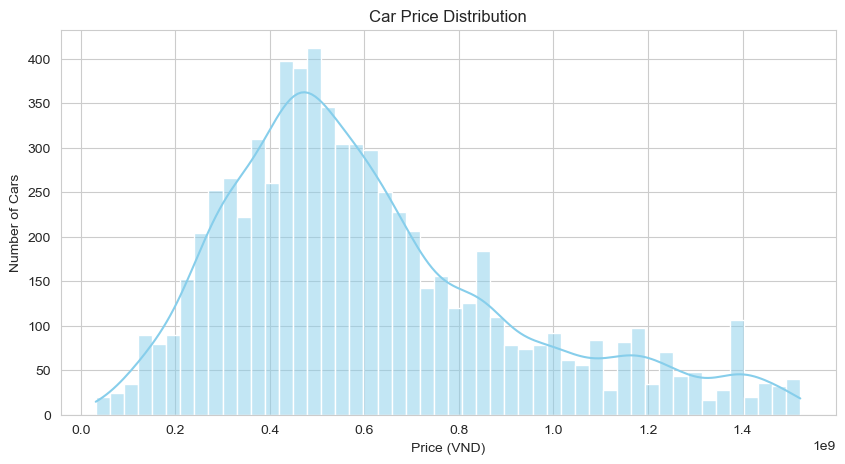

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True, color="skyblue")
plt.title("Car Price Distribution")
plt.xlabel("Price (VND)")
plt.ylabel("Number of Cars")
plt.show()

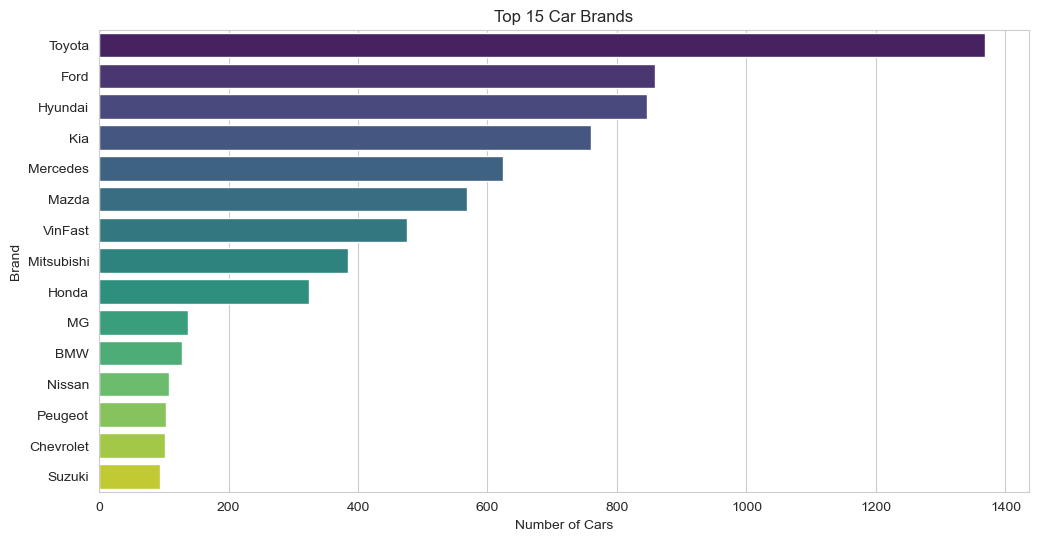

In [9]:
plt.figure(figsize=(12,6))
top_brands = df["brand"].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
plt.title("Top 15 Car Brands")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.show()

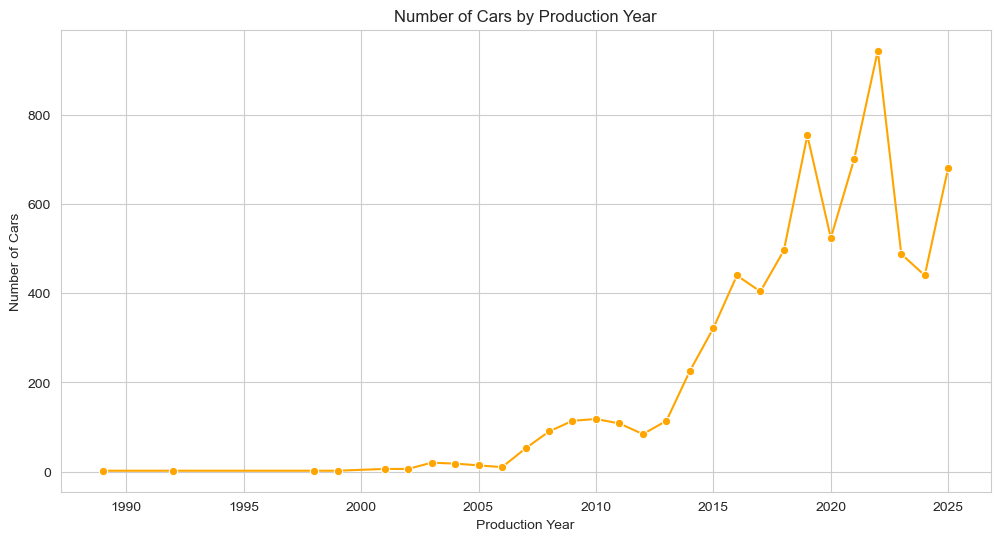

In [10]:
plt.figure(figsize=(12,6))
year_counts = df["year"].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="orange")
plt.title("Number of Cars by Production Year")
plt.xlabel("Production Year")
plt.ylabel("Number of Cars")
plt.show()

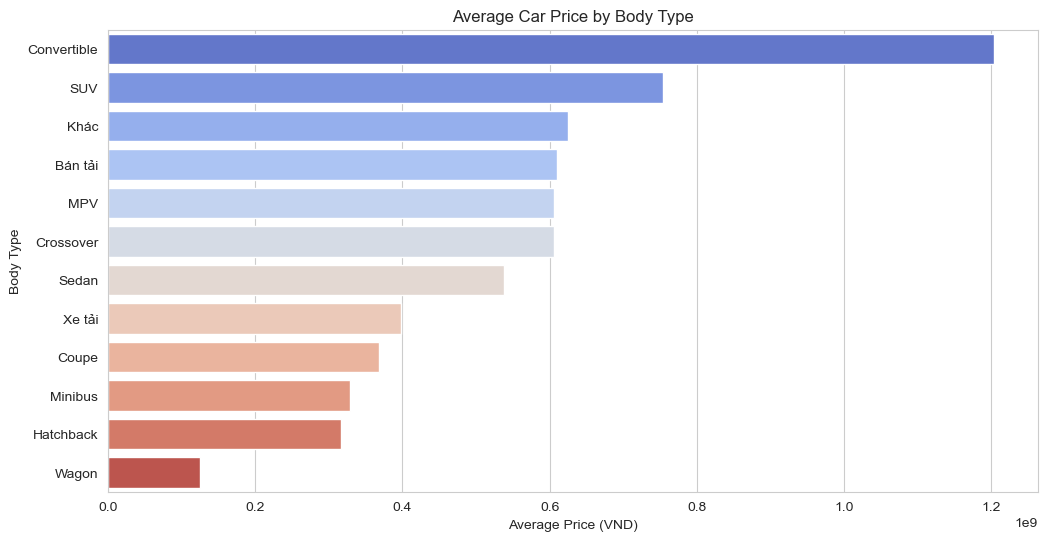

In [11]:
plt.figure(figsize=(12,6))
body_price = df.groupby("body_type")["price"].mean().sort_values(ascending=False)
sns.barplot(x=body_price.values, y=body_price.index, palette="coolwarm")
plt.title("Average Car Price by Body Type")
plt.xlabel("Average Price (VND)")
plt.ylabel("Body Type")
plt.show()

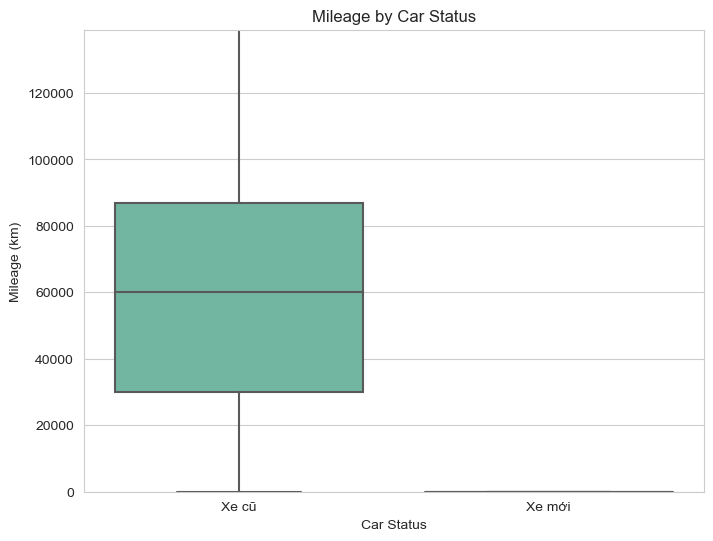

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="status", y="mileage", palette="Set2")
plt.title("Mileage by Car Status")
plt.xlabel("Car Status")
plt.ylabel("Mileage (km)")
plt.ylim(0, df["mileage"].quantile(0.95))
plt.show()

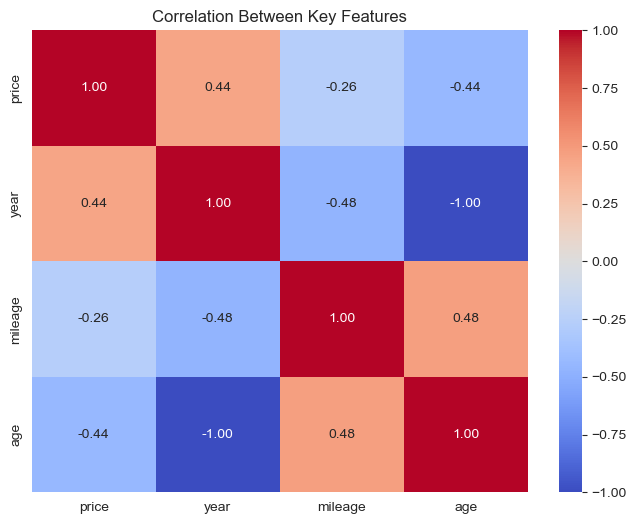

In [13]:
plt.figure(figsize=(8,6))
corr = df[["price", "year", "mileage", "age"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Between Key Features")
plt.show()


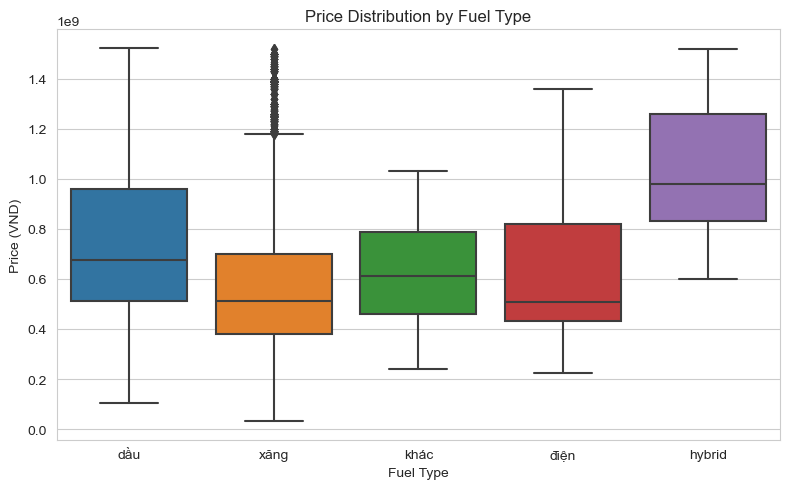

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='fuel_type', y='price')
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.show()